
# Assignment 4 for Course 1MS041
Make sure you pass the `# ... Test` cells and
 submit your solution notebook in the corresponding assignment on the course website. You can submit multiple times before the deadline and your highest score will be used.

---
## Assignment 4, PROBLEM 1
Maximum Points = 24


    This time the assignment only consists of one problem, but we will do a more comprehensive analysis instead.

Consider the dataset `Corona_NLP_train.csv` that you can get from the course website [git](https://github.com/datascience-intro/1MS041-2024/blob/main/notebooks/data/Corona_NLP_train.csv). The data is "Coronavirus tweets NLP - Text Classification" that can be found on [kaggle](https://www.kaggle.com/datasets/datatattle/covid-19-nlp-text-classification). The data has several columns, but we will only be working with `OriginalTweet`and `Sentiment`.

1. [3p] Load the data and filter out those tweets that have `Sentiment`=`Neutral`. Let $X$ represent the `OriginalTweet` and let 
    $$
        Y = 
        \begin{cases}
        1 & \text{if sentiment is towards positive}
        \\
        0 & \text{if sentiment is towards negative}.
        \end{cases}
    $$
    Put the resulting arrays into the variables $X$ and $Y$. Split the data into three parts, train/test/validation where train is 60% of the data, test is 15% and validation is 25% of the data. Do not do this randomly, this is to make sure that we all did the same splits (we are in this case assuming the data is IID as presented in the dataset). That is [train,test,validation] is the splitting layout.

2. [4p] There are many ways to solve this classification problem. The first main issue to resolve is to convert the $X$ variable to something that you can feed into a machine learning model. For instance, you can first use [`CountVectorizer`](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) as the first step. The step that comes after should be a `LogisticRegression` model, but for this to work you need to put together the `CountVectorizer` and the `LogisticRegression` model into a [`Pipeline`](https://scikit-learn.org/1.5/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline). Fill in the variable `model` such that it accepts the raw text as input and outputs a number $0$ or $1$, make sure that `model.predict_proba` works for this. **Hint: You might need to play with the parameters of LogisticRegression to get convergence, make sure that it doesn't take too long or the autograder might kill your code**
3. [3p] Use your trained model and calculate the precision and recall on both classes. Fill in the corresponding variables with the answer.
4. [3p] Let us now define a cost function
    * A positive tweet that is classified as negative will have a cost of 1
    * A negative tweet that is classified as positive will have a cost of 5
    * Correct classifications cost 0
    
    complete filling the function `cost` to compute the cost of a prediction model under a certain prediction threshold (recall our precision recall lecture and the `predict_proba` function from trained models). 

5. [4p] Now, we wish to select the threshold of our classifier that minimizes the cost, fill in the selected threshold value in value `optimal_threshold`.
6. [4p] With your newly computed threshold value, compute the cost of putting this model in production by computing the cost using the validation data. Also provide a confidence interval of the cost using Hoeffdings inequality with a 99% confidence.
7. [3p] Let $t$ be the threshold you found and $f$ the model you fitted (one of the outputs of `predict_proba`), if we define the random variable
    $$
        C = (1-1_{f(X)\geq t})Y+5(1-Y)1_{f(X) \geq t}
    $$
    then $C$ denotes the cost of a randomly chosen tweet. In the previous step we estimated $\mathbb{E}[C]$ using the empirical mean. However, since the threshold is chosen to minimize cost it is likely that $C=0$ or $C=1$ than $C=5$ as such it will have a low variance. Compute the empirical variance of $C$ on the validation set. What would be the confidence interval if we used Bennett's inequality instead of Hoeffding in point 6 but with the computed empirical variance as our guess for the variance?

In [1]:

# Part 1

# Load the data from the file specified in the problem definition and make sure that it is loaded using
# the search path `data/Corona_NLP_train.csv`. This is to make sure the autograder and your computer have the same
# file path and can load the data correctly.

# Contrary to how many other problems are structured, this problem actually requires you to
# have X on the shape (n_samples, ) that is a 1-dimensional array. Otherwise it will cause a bunch
# of errors in the autograder or also in for instance CountVectorizer.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

data = pd.read_csv('data/Corona_NLP_train.csv', encoding='latin1')
data = data[['OriginalTweet', 'Sentiment']]
data = data[data['Sentiment'] != 'Neutral']
data['Sentiment'] = data['Sentiment'].map({'Extremely Positive': 1, 'Positive': 1, 'Extremely Negative': 0, 'Negative': 0})

# Make sure that all your data is numpy arrays and not pandas dataframes or series.
#
X = data['OriginalTweet'].to_numpy()
Y = data['Sentiment'].to_numpy()

# 60, 15, 25 split
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X, Y, test_size=0.4, stratify=Y, random_state=23)

X_val, X_test_2, y_val, y_test_2 = train_test_split(X_test_temp, y_test_temp, test_size=0.375, stratify=y_test_temp, random_state=23)
# remove one element from X_test_2 and add it to X_val
X_val = np.append(X_val, X_test_2[0])
y_val = np.append(y_val, y_test_2[0])
X_test_2 = X_test_2[1:]
y_test_2 = y_test_2[1:]

X_train = X_train_temp
Y_train = y_train_temp
X_test = X_test_2
Y_test = y_test_2
X_valid = X_val
Y_valid = y_val

In [2]:

# Part 2

# Train a machine learning model or pipeline that can take the raw strings from X and predict Y=0,1 depending on the
# sentiment of the tweet. Store the trained model in the variable `model`.
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
vectorizer = CountVectorizer()
pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', LogisticRegression(max_iter=300))
])
pipeline.fit(X_train, Y_train)

model = pipeline

In [5]:

# Part 3

# Evaluate the model on the test set and calculate precision, and recall on both classes. Store the results in the
# variables `precision_0`, `precision_1`, `recall_0`, `recall_1`.

predictions = model.predict(X_test)

# recall 0, where 0s agree in predictions and Y_test over everything that should be 0
all_true_ones = np.sum(Y_test)
all_true_zeroes =  len(Y_test) - all_true_ones

all_predicted_ones = np.sum(predictions)
all_predicted_zeroes = len(predictions) - all_predicted_ones

correctly_predicted_zeroes = np.sum([1 if predictions[i] == 0 and Y_test[i] == 0 else 0 for i in range(len(Y_test))])
correctly_predicted_ones = np.sum([1 if predictions[i] == 1 and Y_test[i] == 1 else 0 for i in range(len(Y_test))])



precision_0 =  correctly_predicted_zeroes / all_predicted_zeroes
precision_1 = correctly_predicted_ones / all_predicted_ones
recall_0 = correctly_predicted_zeroes / all_true_zeroes
recall_1 = correctly_predicted_ones / all_true_ones

In [ ]:

# Part 4

def cost(model,threshold,X,Y):
    # Hint, make sure that the model has a predict_proba method
    # think about how the decision is made based on the probabilities
    # and how the threshold can be used to make the decision.
    # For reference take a look at the lecture notes "Bayes classifier"
    # which contains how the decision is made based on the probabilities when the threshold is 0.5.
    
    # Fill in what is missing to compute the cost and return it
    # Note that we are interested in average cost
    probabilities = model.predict_proba(X) 
    total_cost = 0
    
    def eval_cost(true, predicted):
        if true == predicted:
            return 0
        elif true == 1 and predicted == 0:
            return 1
        else: # true == 0 and predicted == 1
            return 5

    for i in range(len(Y)):
        if probabilities[i][1] >= threshold:
            prediction = 1
        else:
            prediction = 0
        total_cost += eval_cost(Y[i], prediction)

    return total_cost / len(Y) 

In [8]:

# Part 5

# Find the optimal threshold for the model on the test set. Store the threshold in the variable `optimal_threshold`
# and the cost at the optimal threshold in the variable `cost_at_optimal_threshold` evaluated on the test set.

thresholds = np.arange(0.0, 1.01, 0.01)
costs = [cost(model, t, X_valid, Y_valid) for t in thresholds]
min_cost_id = np.argmin(costs)


optimal_threshold = thresholds[min_cost_id]
cost_at_optimal_threshold = min(costs)

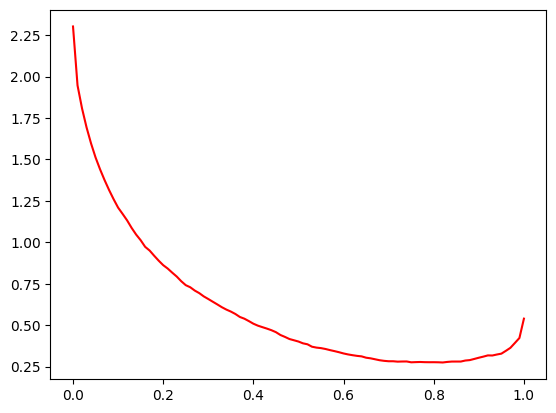

In [10]:
import matplotlib.pyplot as plt

plt.plot(thresholds, costs, "r")
plt.show()

In [12]:

# Part 6

cost_at_optimal_threshold_valid = cost(model, optimal_threshold, X_valid, Y_valid)
n = len(Y_valid)
eps = 5 * np.sqrt((1 / (2*n)) * np.log(2 / 0.01))
lb = cost_at_optimal_threshold_valid - eps
ub = cost_at_optimal_threshold_valid + eps
cost_interval_valid = (lb, ub)

assert(type(cost_interval_valid) == tuple)
assert(len(cost_interval_valid) == 2)

In [13]:

# Part 7

probs = model.predict_proba(X_valid)[:, 1]
preds_val = (probs >= optimal_threshold).astype(int)

costs_at_validation = np.zeros(len(Y_valid))
costs_at_validation = np.array([1 if (Y_valid[i] == 1 and preds_val[i] == 0) else 5 if (Y_valid[i] == 0 and preds_val[i] == 1) else 0 for i in range(len(Y_valid))])

variance_of_C = np.var(costs_at_validation)
term1 = np.sqrt( (2 * variance_of_C * np.log(2/0.01)) / n )

# Term 2: The range term (correction for non-Gaussian tail)
# (M * log(2/alpha)) / (3 * n)
term2 = (5 * np.log(2/0.01)) / (3 * n)

eps_bennett = term1 + term2

# The Interval
# Note: We use the mean cost from the previous step as the center
# If you don't have 'cost_mean' variable, use: np.mean(c_values)
mean_cost = np.mean(costs_at_validation) 

lb = mean_cost - eps_bennett
ub = mean_cost + eps_bennett
interval_of_C = (lb, ub)

assert(type(interval_of_C) == tuple)
assert(len(interval_of_C) == 2)